# Block 6 — Stochastic electromagnetic event generation

## Scientific question

Blocks 4 and 5 built the **mean** electromagnetic shower. At a fixed primary energy and track,
they return the same $18 \times 72$ grid every time. That is a profile, not an event.

This block asks: *what is the smallest physically defensible way to make FastMC produce a
population of electromagnetic events that differ from one another?*

The answer accepted for Block 6A is **one random variable per event** — the depth of shower
maximum $T_0$ — with everything else inherited unchanged from Blocks 4 and 5.

## Why this matters downstream

Every later stage needs an ensemble, not a profile. Block 8 dataset generation, the classical
ML ladder, and the multiscale study of RQ-001 all compare *distributions* of events. Without
event-to-event variation there is nothing to classify, and nothing whose scale structure can be
measured.

## Scope of this notebook

This notebook demonstrates and validates the implementation in `src/ams_ecal/stochastic.py`.
It contains no reusable numerics of its own: every physical quantity comes from tested library
code, in line with the notebook policy in `AGENTS.md`.

In [1]:
from importlib.metadata import version
from math import exp, log
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ams_ecal.fastmc_config import config_digest, load_fastmc_config
from ams_ecal.geometry import load_geometry
from ams_ecal.lateral import AMSLateralShowerModel
from ams_ecal.longitudinal import AMSLongitudinalGammaModel
from ams_ecal.stochastic import StochasticEMShowerModel
from ams_ecal.tracking import TrackState

PROJECT_ROOT = Path.cwd().parent
GEOMETRY_CONFIG_PATH = PROJECT_ROOT / "configs" / "geometry.yaml"
FASTMC_CONFIG_PATH = PROJECT_ROOT / "configs" / "fastmc.yaml"

geometry = load_geometry(GEOMETRY_CONFIG_PATH)
fastmc_config = load_fastmc_config(FASTMC_CONFIG_PATH)

longitudinal = AMSLongitudinalGammaModel(
    config=fastmc_config.longitudinal_em,
    geometry=geometry,
    regime=fastmc_config.regime,
)
lateral = AMSLateralShowerModel(
    config=fastmc_config.lateral_em,
    geometry=geometry,
)
model = StochasticEMShowerModel(
    config=fastmc_config.stochastic_em,
    longitudinal=longitudinal,
    lateral=lateral,
)

CONFIGURATION_SHA256 = config_digest([GEOMETRY_CONFIG_PATH, FASTMC_CONFIG_PATH])
# Read the real installed version rather than hard-coding one: an event that
# records the wrong simulation version is worse than one recording none.
SIMULATION_VERSION = version("ams-ecal-qml")

print(f"Regime                    : {model.regime}")
print(f"Effective critical energy : {model.critical_energy_mev:.2f} MeV")
print(f"Fixed gamma rate beta     : {longitudinal.config.gamma_rate}")
print(f"Readout grid              : {geometry.number_of_layers} x {geometry.cells_per_layer}")
print(f"Simulation version        : {SIMULATION_VERSION}")
print(f"Configuration SHA-256     : {CONFIGURATION_SHA256}")

Regime                    : sampling
Effective critical energy : 7.60 MeV
Fixed gamma rate beta     : 0.65
Readout grid              : 18 x 72
Simulation version        : 0.3.0
Configuration SHA-256     : d56bd6331b0a76ec78a85cda80bce5200e69df82ecc255c10ffb3bef8bebfa01


## One random variable, not eighteen

A tempting but wrong approach is to add independent noise to each of the 18 layer energies.
That would destroy the physics: a real shower that starts late is deep in **every** layer at
once. Its layer energies are strongly correlated, not independently jittered.

The accepted model therefore fluctuates the *shape* of the profile, through a single variable:

$$
\bar{T}(E) = \ln\!\left(\frac{E}{E_c}\right) + C_{\text{regime}},
\qquad
\ln T_0 \sim \mathcal{N}\!\left(\mu(E),\, s(E)^2\right),
\qquad
\alpha_{\text{event}} = 1 + \beta\, T_0 .
$$

Because $\alpha$ is what parameterizes the gamma profile, one draw of $T_0$ re-shapes all 18
layers coherently.

$\beta$ stays **fixed** at $0.65$. That value has peer-reviewed AMS provenance, and letting it
fluctuate as well would introduce a second latent variable that the project cannot currently
identify from the available evidence.

$T_0$ is lognormal rather than normal because a shower maximum is a **positive** depth. A
normal distribution would assign non-zero probability to $T_0 \le 0$, which is not a shower.

The offset $C_{	ext{regime}}$ and the width $s(E)$ both depend on the **regime**, which is the
subject of the next section.

## The width law, and an honest label for it

The relative width of $T_0$ is

$$
s(E) \;=\; \frac{1}{-2.5 + 1.25\,\ln(E/E_c)} .
$$

> **Provenance: transferred approximation.**
> This law comes from the Grindhammer and Peters parameterization of electromagnetic showers in
> sampling calorimeters, the structure retained by the GFlash parameterization in Geant4. It is
> **not** an AMS-specific fitted fluctuation width: no AMS publication known to this project
> reports a measured width for the AMS ECAL shower-maximum distribution.
>
> $\beta = 0.65$ is AMS-specific evidence. $s(E)$ is not. The two constants in this model do
> **not** have the same epistemic status, and the configuration file records that difference.

Whether the transfer is adequate is a question for later comparison against detailed Geant4
transport, not something this notebook can settle.

### The law has a pole

The denominator vanishes at $E/E_c = e^{2}$ and is negative below it. With $E_c = 7.6$ MeV that
places a validity floor near **56 MeV** — *above* the floor near 12.5 MeV where $\bar{T}$ of the
mean model would go negative. So the binding domain constraint belongs to the stochastic block,
which raises rather than silently returning a negative width.

In [2]:
energies_gev = np.array([1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0])
widths = np.array([model.fluctuation_width(e * 1e3) for e in energies_gev])
mean_depths = np.array([longitudinal.shower_max_depth_x0(e * 1e3) for e in energies_gev])

print(" E [GeV] |  T_bar [X0] |   s(E)  | spread of T0 [X0]")
print("---------+-------------+---------+------------------")
for e, t_bar, s in zip(energies_gev, mean_depths, widths):
    print(f"{e:8.0f} | {t_bar:11.3f} | {s:7.4f} | {t_bar * s:16.3f}")

pole_energy_mev = model.critical_energy_mev * exp(2.0)
print(f"\nValidity floor of the width law: {pole_energy_mev:.1f} MeV")

try:
    model.fluctuation_width(0.9 * pole_energy_mev)
except ValueError as error:
    print(f"Below it the model raises: {error}")

 E [GeV] |  T_bar [X0] |   s(E)  | spread of T0 [X0]
---------+-------------+---------+------------------
       1 |       3.714 |  0.2778 |            1.032
       3 |       4.813 |  0.2011 |            0.968
      10 |       6.017 |  0.1544 |            0.929
      30 |       7.115 |  0.1274 |            0.906
     100 |       8.319 |  0.1069 |            0.889
     300 |       9.418 |  0.0932 |            0.878
    1000 |      10.622 |  0.0817 |            0.868

Validity floor of the width law: 56.2 MeV
Below it the model raises: primary_energy_mev is below the valid domain of the stochastic shower-maximum width law


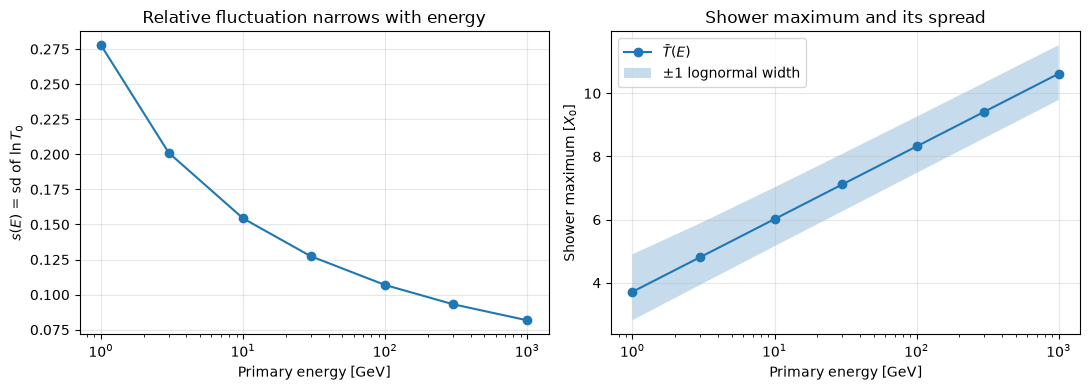

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogx(energies_gev, widths, "o-")
axes[0].set_xlabel("Primary energy [GeV]")
axes[0].set_ylabel(r"$s(E)$ = sd of $\ln T_0$")
axes[0].set_title("Relative fluctuation narrows with energy")
axes[0].grid(alpha=0.3)

axes[1].semilogx(energies_gev, mean_depths, "o-", label=r"$\bar{T}(E)$")
axes[1].fill_between(
    energies_gev,
    mean_depths * np.exp(-widths),
    mean_depths * np.exp(widths),
    alpha=0.25,
    label=r"$\pm 1$ lognormal width",
)
axes[1].set_xlabel("Primary energy [GeV]")
axes[1].set_ylabel(r"Shower maximum [$X_0$]")
axes[1].set_title("Shower maximum and its spread")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Why the location parameter is $\ln \bar{T} - \tfrac{1}{2}s^2$

This is the subtlest line in the model, and it is worth being explicit about.

For a lognormal variable with $\ln T_0 \sim \mathcal{N}(\mu, s^2)$,

$$
\mathbb{E}[T_0] \;=\; \exp\!\left(\mu + \tfrac{1}{2}s^2\right).
$$

The *median* is $e^{\mu}$, but the **mean** is larger, because the lognormal has a long upper
tail. So had we naively set $\mu = \ln \bar{T}(E)$ — the obvious-looking choice — the average
sampled shower maximum would have come out at $\bar{T}(E)\,e^{s^2/2}$, biased systematically
**deep**.

Subtracting $\tfrac{1}{2}s^2$ cancels exactly that factor:

$$
\mu(E) = \ln \bar{T}(E) - \tfrac{1}{2}s(E)^2
\quad\Longrightarrow\quad
\mathbb{E}[T_0] = \bar{T}(E).
$$

The stochastic model therefore **reduces on average to the accepted mean model**. That is a
design requirement, not an accident: Block 6A must add variance without moving the mean that
Blocks 4 and 5 already validated.

In [4]:
energy_mev = 100_000.0
rng = np.random.default_rng(20260921)
sample_count = 200_000

centred = np.array(
    [model.sample_shower_max_depth_x0(energy_mev, rng) for _ in range(sample_count)]
)

width = model.fluctuation_width(energy_mev)
target_mean_x0 = longitudinal.shower_max_depth_x0(energy_mev)

# The naive alternative, shown for contrast only: mu = ln(T_bar), no centring.
uncentred = np.exp(rng.normal(log(target_mean_x0), width, size=sample_count))

print(f"Target  T_bar(E)                 : {target_mean_x0:.4f} X0")
print(f"Centred model, mean of T0        : {centred.mean():.4f} X0")
print(f"Uncentred alternative, mean      : {uncentred.mean():.4f} X0")
print(f"Predicted bias factor exp(s^2/2) : {exp(0.5 * width ** 2):.5f}")
print(f"Observed  bias factor            : {uncentred.mean() / target_mean_x0:.5f}")
print()
print(f"sd of ln(T0), sampled            : {np.log(centred).std(ddof=1):.5f}")
print(f"sd of ln(T0), configured s(E)    : {width:.5f}")

Target  T_bar(E)                 : 8.3194 X0
Centred model, mean of T0        : 8.3218 X0
Uncentred alternative, mean      : 8.3664 X0
Predicted bias factor exp(s^2/2) : 1.00573
Observed  bias factor            : 1.00564

sd of ln(T0), sampled            : 0.10689
sd of ln(T0), configured s(E)    : 0.10688


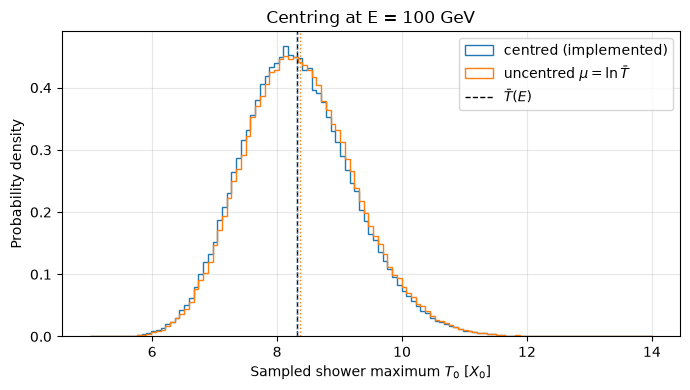

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(5.0, 14.0, 120)

ax.hist(centred, bins=bins, histtype="step", density=True, label="centred (implemented)")
ax.hist(
    uncentred,
    bins=bins,
    histtype="step",
    density=True,
    label=r"uncentred $\mu=\ln\bar{T}$",
)
ax.axvline(target_mean_x0, color="k", ls="--", lw=1, label=r"$\bar{T}(E)$")
ax.axvline(centred.mean(), color="C0", ls=":", lw=1)
ax.axvline(uncentred.mean(), color="C1", ls=":", lw=1)
ax.set_xlabel(r"Sampled shower maximum $T_0$ [$X_0$]")
ax.set_ylabel("Probability density")
ax.set_title(f"Centring at E = {energy_mev / 1e3:.0f} GeV")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## From one draw to 18 layer energies

Each sampled $T_0$ gives $\alpha_{\text{event}} = 1 + \beta T_0$, and the *same* gamma-profile
machinery from Block 4 is then integrated over the 18 finite readout intervals. The stochastic
block calls `layer_energy_fractions_for_shape`, which the deterministic model now also uses, so
there is exactly one implementation of the integration.

Fractions are **not** renormalized to the 17 $X_0$ detector depth, so the deficit from unity
stays physical longitudinal leakage. A shower that happens to develop late genuinely loses more
energy out of the back.

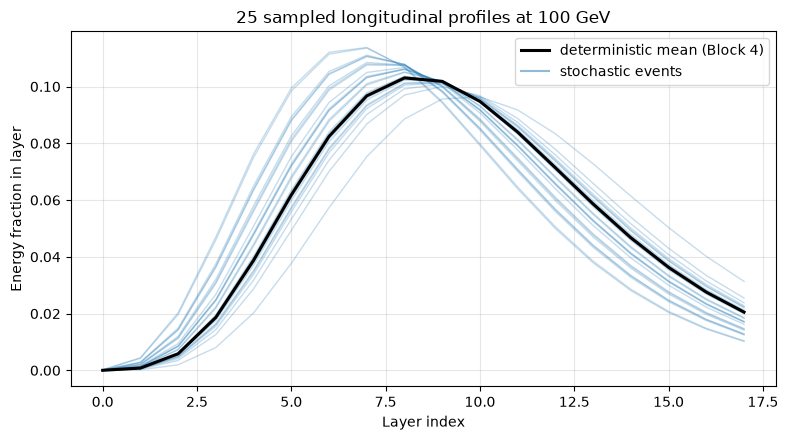

In [6]:
rng = np.random.default_rng(7)
layer_index = np.arange(geometry.number_of_layers)

fig, ax = plt.subplots(figsize=(8, 4.5))

for _ in range(25):
    fractions = model.sample_layer_energy_fractions(energy_mev, rng)
    ax.plot(layer_index, fractions, color="C0", alpha=0.25, lw=1)

mean_fractions = longitudinal.layer_energy_fractions(energy_mev)
ax.plot(layer_index, mean_fractions, "k-", lw=2.2, label="deterministic mean (Block 4)")
ax.plot([], [], color="C0", alpha=0.5, label="stochastic events")
ax.set_xlabel("Layer index")
ax.set_ylabel("Energy fraction in layer")
ax.set_title(f"25 sampled longitudinal profiles at {energy_mev / 1e3:.0f} GeV")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## The lateral profile is deliberately left deterministic

Block 6A applies the **unchanged** Block 5 lateral grid to each stochastic layer energy. Every
event-to-event difference therefore enters through the longitudinal shape alone.

This is an explicit, recorded limitation rather than an oversight. A stochastic lateral model
would need its own evidence pass: lateral fluctuations are driven by different physics
(multiple scattering, individual hard bremsstrahlung, the fibre sampling structure), and they
were excluded from the accepted Block 6A model.

The practical consequence is that within any one layer, the 72 cell energies are a fixed shape
scaled by one fluctuating number.

Event id           : notebook-demo-000001
Grid shape         : (18, 72)
Total ECAL energy  : 94,355.0 MeV
Contained fraction : 0.9436
Deepest layer      : 9


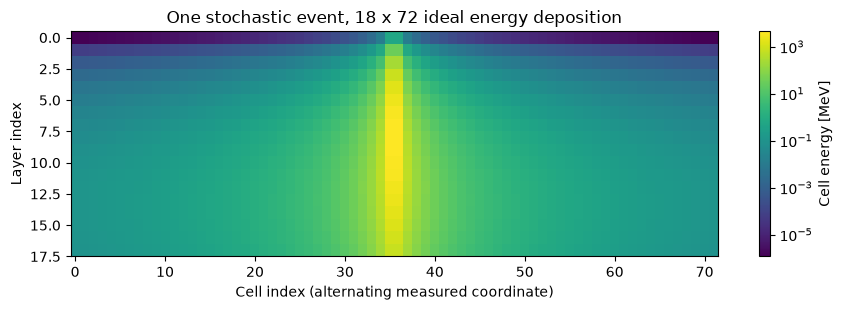

In [7]:
track = TrackState(x0_mm=0.0, y0_mm=0.0, z0_mm=0.0, theta_rad=0.0, phi_rad=0.0)

event = model.generate_event(
    event_id="notebook-demo-000001",
    primary_energy_mev=energy_mev,
    track=track,
    random_seed=20260921,
    simulation_version=SIMULATION_VERSION,
    configuration_sha256=CONFIGURATION_SHA256,
)

grid = np.array(event.cell_energies_mev)
print(f"Event id           : {event.event_id}")
print(f"Grid shape         : {grid.shape}")
print(f"Total ECAL energy  : {event.total_ecal_energy_mev:,.1f} MeV")
print(f"Contained fraction : {event.total_ecal_energy_mev / energy_mev:.4f}")
print(f"Deepest layer      : {int(np.argmax(grid.sum(axis=1)))}")

fig, ax = plt.subplots(figsize=(9, 3.2))
image = ax.imshow(grid, aspect="auto", origin="upper", norm="log", cmap="viridis")
ax.set_xlabel("Cell index (alternating measured coordinate)")
ax.set_ylabel("Layer index")
ax.set_title("One stochastic event, 18 x 72 ideal energy deposition")
fig.colorbar(image, ax=ax, label="Cell energy [MeV]")
fig.tight_layout()
plt.show()

## Ensembles, and a real statistical subtlety

Now generate a population. Two things are worth measuring:

1. the spread of the reconstructed shower maximum and of containment;
2. whether the ensemble-mean containment equals the deterministic containment.

**It does not**, and that is expected rather than a bug. Containment is a *non-linear* function
of $T_0$, so by the Jensen inequality

$$
\mathbb{E}\big[\text{contained}(T_0)\big] \;\neq\; \text{contained}\big(\mathbb{E}[T_0]\big).
$$

The centring guarantee holds in $T_0$, **not** in containment. Because the contained fraction of
the gamma profile is concave in $T_0$ over the relevant range — a deeper shower loses more out
of the back than a shallower one gains — the ensemble mean sits slightly *below* the
deterministic value.

This is exactly the kind of quantity that must not be asserted as an equality in a test, and the
test suite deliberately does not assert it.

In [8]:
ensemble_size = 4000
events = list(
    model.generate_events(
        primary_energies_mev=(energy_mev,) * ensemble_size,
        tracks=(track,) * ensemble_size,
        base_seed=2026,
        simulation_version=SIMULATION_VERSION,
        configuration_sha256=CONFIGURATION_SHA256,
    )
)

layer_profiles = np.array([e.layer_energies_mev for e in events])
contained = layer_profiles.sum(axis=1) / energy_mev
deepest_layer = layer_profiles.argmax(axis=1)

deterministic_contained = sum(
    mean_fraction * sum(layer_row)
    for mean_fraction, layer_row in zip(
        longitudinal.layer_energy_fractions(energy_mev),
        lateral.track_centered_cell_fractions(track, energy_mev),
        strict=True,
    )
)

print(f"Ensemble size                    : {ensemble_size}")
print(f"Deepest layer, mean              : {deepest_layer.mean():.3f}")
print(f"Deepest layer, range             : {deepest_layer.min()} to {deepest_layer.max()}")
print()
print(f"Contained fraction, deterministic: {deterministic_contained:.5f}")
print(f"Contained fraction, ensemble mean: {contained.mean():.5f}")
print(f"Jensen offset (ensemble - det.)  : {contained.mean() - deterministic_contained:+.5f}")
print(f"Contained fraction, sd           : {contained.std(ddof=1):.5f}")
print()
print(f"Largest total / E over events    : {contained.max():.5f}")
print("(must stay below 1: the remainder is physical leakage)")

Ensemble size                    : 4000
Deepest layer, mean              : 8.332
Deepest layer, range             : 5 to 12

Contained fraction, deterministic: 0.94943
Contained fraction, ensemble mean: 0.94557
Jensen offset (ensemble - det.)  : -0.00385
Contained fraction, sd           : 0.02452

Largest total / E over events    : 0.98989
(must stay below 1: the remainder is physical leakage)


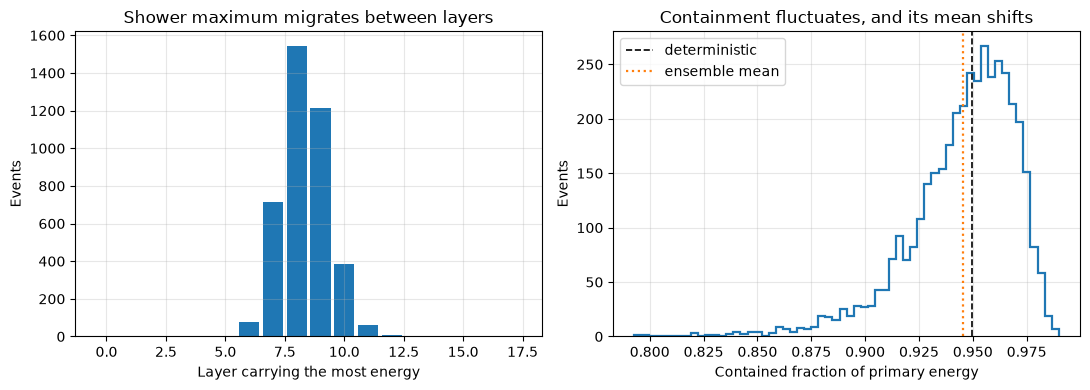

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(
    deepest_layer,
    bins=np.arange(-0.5, geometry.number_of_layers + 0.5),
    rwidth=0.85,
)
axes[0].set_xlabel("Layer carrying the most energy")
axes[0].set_ylabel("Events")
axes[0].set_title("Shower maximum migrates between layers")
axes[0].grid(alpha=0.3)

axes[1].hist(contained, bins=60, histtype="step", lw=1.6)
axes[1].axvline(deterministic_contained, color="k", ls="--", lw=1.2, label="deterministic")
axes[1].axvline(contained.mean(), color="C1", ls=":", lw=1.6, label="ensemble mean")
axes[1].set_xlabel("Contained fraction of primary energy")
axes[1].set_ylabel("Events")
axes[1].set_title("Containment fluctuates, and its mean shifts")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Reproducibility and provenance

Randomness without provenance is not science. Three properties are guaranteed by construction:

- **an event is reproducible from its own recorded seed alone**, because `generate_event` builds
  its own generator, so an event does not depend on how many events preceded it;
- **ensemble seeds are independent**, because `spawn_event_seeds` uses `SeedSequence` spawning,
  which guarantees statistically independent streams, unlike `base_seed + index` arithmetic;
- **the configuration is hashed into every event**, because `config_digest` covers the geometry
  and FastMC configuration bytes, so an event carries the scientific inputs that produced it.

The seed-isolation and split-integrity requirements of Block 8 will rest on these.

In [10]:
def demo_event(seed: int):
    return model.generate_event(
        event_id=f"repro-{seed:06d}",
        primary_energy_mev=energy_mev,
        track=track,
        random_seed=seed,
        simulation_version=SIMULATION_VERSION,
        configuration_sha256=CONFIGURATION_SHA256,
    )


same_a, same_b = demo_event(42), demo_event(42)
other = demo_event(43)

# Order independence: generate five, then regenerate the third on its own.
in_sequence = [demo_event(seed) for seed in (10, 11, 12, 13, 14)]
alone = demo_event(12)

print(f"Same seed reproduces event      : {same_a.cell_energies_mev == same_b.cell_energies_mev}")
print(f"Different seed differs          : {other.cell_energies_mev != same_a.cell_energies_mev}")
print(f"Independent of generation order : {in_sequence[2].cell_energies_mev == alone.cell_energies_mev}")

seeds = model.spawn_event_seeds(base_seed=2026, count=1000)
print(f"Spawned seeds all distinct      : {len(set(seeds)) == len(seeds)}")
print(f"Spawning is reproducible        : {seeds == model.spawn_event_seeds(2026, 1000)}")
print()
print("Provenance carried by one event:")
print(f"  backend    : {same_a.provenance.simulation_backend}")
print(f"  version    : {same_a.provenance.simulation_version}")
print(f"  config hash: {same_a.provenance.configuration_sha256}")
print(f"  seed       : {same_a.provenance.random_seed}")

Same seed reproduces event      : True
Different seed differs          : True
Independent of generation order : True
Spawned seeds all distinct      : True
Spawning is reproducible        : True

Provenance carried by one event:
  backend    : fastmc
  version    : 0.3.0
  config hash: d56bd6331b0a76ec78a85cda80bce5200e69df82ecc255c10ffb3bef8bebfa01
  seed       : 42


## Two regimes, and the perfect event

The constants above are not free knobs. Grindhammer and Peters parameterize the mean depth **and**
the fluctuation width separately for two regimes, and the pair must be kept together:

| regime | what it describes | offset | $s(E)$ at 100 GeV |
|---|---|---|---|
| `deposition` | true energy deposition in the lead/fibre composite - the **perfect event** | PDG $-0.5$ | 0.0948 |
| `sampling` | signal-level shape, already distorted because only the fibres are read out | G&P $-0.812$ plus a geometry shift | 0.1069 |

The sampling regime peaks **shallower**, because $e/mip$ falls with depth as the cascade softens
and low-energy photons are absorbed preferentially in the lead. It also fluctuates **more**,
because the sampling process itself adds longitudinal shape fluctuation.

Two notes on provenance. First, the sampling depth shift is computed from
`configs/geometry.yaml` rather than hard-coded, so it tracks the detector description. Second,
AMS publishes **no** mean-depth formula at all: verification of Kounine et al. 2017 and AMS
Physics Reports 894 confirms the per-shower parameters are obtained by fitting observed ECAL
deposits. There is no AMS $ar{T}}(E)$ to be faithful to, so the obligation is internal
coherence rather than matching an AMS constant that does not exist.

### Recovering the perfect event from the seed

The generator draws **one standard normal variate from the seed first**, and only then applies the
regime-dependent transformation. The randomness belongs to the seed; the physics belongs to the
regime. So a single seed names a *pair* of events, and

```python
model.true_deposition().generate_event(..., random_seed=s)
```

returns the perfect, true-deposition event lying behind the sampled event that seed `s` produced.

This is what keeps the block boundary usable. Block 7 adds the impurities - noise, thresholds,
gains, saturation, dead channels - and under `regime: sampling` it must **not** re-apply the depth
shift or the extra shape fluctuation, because those are already here.

In [11]:
perfect = model.true_deposition()

print(f"{'':22s} {'sampling':>12s} {'deposition':>12s}")
print("-" * 48)
print(f"{'regime':22s} {model.regime:>12s} {perfect.regime:>12s}")
print(
    f"{'mean T_bar [X0]':22s} "
    f"{longitudinal.shower_max_depth_x0(energy_mev):>12.4f} "
    f"{perfect.longitudinal.shower_max_depth_x0(energy_mev):>12.4f}"
)
print(
    f"{'sigma(ln T0)':22s} "
    f"{model.fluctuation_width(energy_mev):>12.4f} "
    f"{perfect.fluctuation_width(energy_mev):>12.4f}"
)
print(
    f"{'sampling shift [X0]':22s} "
    f"{longitudinal.sampling_shower_max_correction_x0:>12.4f} "
    f"{perfect.longitudinal.sampling_shower_max_correction_x0:>12.4f}"
)
print()
print(f"F_S = {longitudinal.sampling_frequency:.4f}   "
      f"e/mip = {longitudinal.electron_to_mip_ratio:.4f}  (both from geometry.yaml)")
print()

print("one seed, two corresponding events:")
print("  seed    | sampled T0 | perfect T0 | quantile z (must agree)")
for seed in (7, 42, 20260928):
    sampled_x0 = model.sample_shower_max_depth_x0(
        energy_mev, np.random.default_rng(seed)
    )
    perfect_x0 = perfect.sample_shower_max_depth_x0(
        energy_mev, np.random.default_rng(seed)
    )
    z_sampled = (
        np.log(sampled_x0) - model.lognormal_location(energy_mev)
    ) / model.fluctuation_width(energy_mev)
    z_perfect = (
        np.log(perfect_x0) - perfect.lognormal_location(energy_mev)
    ) / perfect.fluctuation_width(energy_mev)
    print(
        f"  {seed:>8d} | {sampled_x0:10.4f} | {perfect_x0:10.4f} | "
        f"{z_sampled:+.6f} vs {z_perfect:+.6f}"
    )

                           sampling   deposition
------------------------------------------------
regime                     sampling   deposition
mean T_bar [X0]              8.3194       8.9848
sigma(ln T0)                 0.1069       0.0948
sampling shift [X0]         -0.3534       0.0000

F_S = 4.8971   e/mip = 0.6507  (both from geometry.yaml)

one seed, two corresponding events:
  seed    | sampled T0 | perfect T0 | quantile z (must agree)
         7 |     8.2731 |     8.9456 | +0.001230 vs +0.001230
        42 |     8.5459 |     9.2066 | +0.304717 vs +0.304717
  20260928 |     7.8811 |     8.5686 | -0.452972 vs -0.452972


## The deterministic limit

The strongest structural check available: drive $s(E) \to 0$ and the stochastic generator
must converge on the Block 4 and 5 deterministic grid. Were that to fail, Block 6A would be a
*different* model that merely resembles the accepted one, rather than the accepted mean model
plus noise.

The convergence is a *limit*, not an identity, so the honest test is that the residual vanishes
**in proportion** to the width, rather than that it is exactly zero at some arbitrary
tolerance. Checking the proportionality also measures something physically interesting: the
constant of proportionality is the amplification from a relative error in $T_0$ to a relative
error in the layer energies.

In [12]:
from ams_ecal.fastmc_config import StochasticEMConfig

deterministic_layer_energies = np.array(
    [
        mean_energy_mev * sum(layer_row)
        for mean_energy_mev, layer_row in zip(
            longitudinal.mean_layer_energies_mev(energy_mev),
            lateral.track_centered_cell_fractions(track, energy_mev),
            strict=True,
        )
    ]
)
def deterministic_limit_residual(target_width, seeds=5):
    # Largest relative layer-energy deviation at a forced fluctuation width.
    degenerate = StochasticEMShowerModel(
        config=StochasticEMConfig(
            deposition_width_intercept=1.0 / target_width,
            deposition_width_log_slope=0.0,
            sampling_width_intercept=1.0 / target_width,
            sampling_width_log_slope=0.0,
        ),
        longitudinal=longitudinal,
        lateral=lateral,
    )
    worst = 0.0
    for seed in range(seeds):
        limit_event = degenerate.generate_event(
            event_id=f"deterministic-limit-{seed}",
            primary_energy_mev=energy_mev,
            track=track,
            random_seed=seed,
            simulation_version=SIMULATION_VERSION,
            configuration_sha256=CONFIGURATION_SHA256,
        )
        deviation = (
            np.abs(np.array(limit_event.layer_energies_mev) - deterministic_layer_energies)
            / deterministic_layer_energies
        )
        worst = max(worst, float(deviation.max()))
    return worst


residuals = {w: deterministic_limit_residual(w) for w in (1e-9, 1e-12, 1e-15)}

print("forced s(E) | largest relative layer deviation | amplification")
print("------------+----------------------------------+--------------")
for target_width, residual in residuals.items():
    print(f"   {target_width:.0e}   |            {residual:.3e}             |  {residual / target_width:8.1f}")

print()
print("The residual falls in proportion to the forced width, so it is that")
print("deliberately non-zero width propagating through the profile, not a")
print("numerical defect. The amplification is the factor by which a relative")
print("error in T0 is magnified into a relative error in the layer energies -")
print("which is precisely why T0 works as a single effective latent variable.")

forced s(E) | largest relative layer deviation | amplification
------------+----------------------------------+--------------
   1e-09   |            2.685e-08             |      26.9
   1e-12   |            2.686e-11             |      26.9
   1e-15   |            2.887e-14             |      28.9

The residual falls in proportion to the forced width, so it is that
deliberately non-zero width propagating through the profile, not a
numerical defect. The amplification is the factor by which a relative
error in T0 is magnified into a relative error in the layer energies -
which is precisely why T0 works as a single effective latent variable.


## Scientific invariants

The assertions below restate, inside the notebook, the properties enforced by
`tests/test_stochastic.py`. They are the claims this block makes.

In [13]:
# 1. The centring identity: E[T0] = T_bar(E).
standard_error = centred.std(ddof=1) / np.sqrt(centred.size)
assert abs(centred.mean() - target_mean_x0) < 4.0 * standard_error

# 2. The configured width is recovered in log space.
assert abs(np.log(centred).std(ddof=1) - width) / width < 0.02

# 3. Energy is never created: the deficit is leakage.
assert (layer_profiles.sum(axis=1) <= energy_mev).all()

# 4. The fluctuation is real.
assert len(set(deepest_layer.tolist())) > 1
assert contained.std(ddof=1) > 0.0

# 5. The deterministic limit is approached in proportion to the forced width,
#    so the residual is the width itself and not a numerical defect.
assert residuals[1e-12] < 1.0e-9
assert 0.5 < (residuals[1e-9] / residuals[1e-12]) / 1.0e3 < 2.0

# 6. The width law refuses to extrapolate below its pole.
try:
    model.fluctuation_width(0.5 * pole_energy_mev)
except ValueError:
    pass
else:
    raise AssertionError("the width law must reject energies below its pole")

print("All Block 6 invariants hold.")

All Block 6 invariants hold.


## Scope, and handoff to Block 7

**What this block establishes.** FastMC now produces reproducible electromagnetic *events* whose
longitudinal development fluctuates coherently, centred on the previously validated mean model,
with leakage preserved and full seed and configuration provenance.

**What it deliberately does not do.**

| Excluded from Block 6A | Why |
|---|---|
| Fluctuating $\beta$ | AMS itself holds $b = 0.65$ fixed for all showers and all energies and fits $T_0$ per shower, so this matches AMS; the two-variable model is the outlier |
| Explicit shower-start sampling | The accepted origin convention is detector-entry referenced |
| Independent per-layer noise | Would destroy the physical correlation between layers |
| A stochastic lateral model | Different physics; needs its own evidence pass |
| Proton and hadronic showers | Block 6B; no accepted model exists yet |

**What the energies here mean.** Under `regime: deposition` they are *ideal deposits in the lead
and fibre composite* - the perfect event, with no detector effect of any kind. Under
`regime: sampling`, the default, the longitudinal **shape** has already been moved to signal
level, but nothing else has: no photostatistics, light attenuation, noise, threshold, gain,
saturation or dead-channel effect. Those are the impurities Block 7 adds.

**The open question Block 7 inherits.** AMS obtains its shower parameters, including
$\beta = 0.65$, by fitting *observed* energy deposits in ECAL cells rather than true deposition.
Some detector behaviour is therefore already absorbed into the constants this block uses. How
much, and what a Block 7 response model would consequently **double-count**, is unquantified,
and it is the central question of the Block 7 evidence pass. The premise is now verified
directly against Kounine et al. 2017 and AMS Physics Reports 894.

The regime switch is the practical mitigation: build Block 7 against `regime: deposition`, where
nothing detector-related has been applied, and the double-counting surface shrinks to the
fitted-parameter question alone.

That is a question about evidence rather than about code, which is why Block 7 begins with a
literature and verification pass rather than an implementation.